In [24]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset,TensorDataset
from transformers import BertTokenizerFast, BertModel, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
import random
from sklearn.metrics import precision_recall_curve, auc, roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
file_path = 'Phishing_Email.csv'  # Update the file path if needed
data = pd.read_csv(file_path)

In [2]:
# Function to load data and handle possible encoding issues
def load_data(file_path):
    try:
        return pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(file_path, encoding='ISO-8859-1')


# Drop the 'Unnamed: 0' column if it exists and is unnecessary
if 'Unnamed: 0' in data.columns:
    data.drop('Unnamed: 0', axis=1, inplace=True)

# Handling missing values by removing rows with missing 'Email Text'
data.dropna(subset=['Email Text'], inplace=True)
data['Email Text'] = data['Email Text'].apply(lambda x: x.strip())
data = data[data['Email Text'].astype(bool)]

# Function to clean the text data
def clean_text(text):
    text = text.encode('ascii', errors='ignore').decode()  # Convert to ASCII
    text = re.sub(r'\n', ' ', text)  # Replace new lines with space
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

# Apply the text cleaning function to the 'Email Text' column
data['Email Text'] = data['Email Text'].apply(clean_text)

# Save the cleaned data to a new CSV file
data.to_csv('Cleaned_Phishing_Email.csv', index=False)

# Save the cleaned data to a JSON file (suitable for web applications and hierarchical data support)
data.to_json('Cleaned_Phishing_Email.json', orient='records', lines=True)

# Display the first few rows of the cleaned data to verify
print(data.head())

                                          Email Text      Email Type
0  re : 6 . 1100 , disc : uniformitarianism , re ...      Safe Email
1  the other side of * galicismos * * galicismo *...      Safe Email
2  re : equistar deal tickets are you still avail...      Safe Email
3  Hello I am your hot lil horny toy. I am the on...  Phishing Email
4  software at incredibly low prices ( 86 % lower...  Phishing Email


In [3]:
# Function to load data from a JSON file
def load_data(file_path):
    return pd.read_json(file_path, lines=True)  # Assuming each record is on a new line

# Load the dataset
file_path = 'Cleaned_Phishing_Email.json'
data = load_data(file_path)

# Calculate the total counts of each type
counts = data['Email Type'].value_counts()
total_phishing = counts.get('Phishing Email', 0)
total_safe = counts.get('Safe Email', 0)

# Calculate target counts to achieve a 60% Safe Email and 40% Phishing Email distribution
target_total = total_safe + total_phishing
target_safe = int(0.6 * target_total)
target_phishing = int(0.4 * target_total)

# Calculate how many 'Safe Email' rows to drop to achieve the target ratio
safe_to_drop = total_safe - target_safe

if safe_to_drop > 0:
    # Randomly select 'safe_to_drop' number of Safe Email entries to drop
    safe_indices = data[data['Email Type'] == 'Safe Email'].index
    drop_indices = np.random.choice(safe_indices, safe_to_drop, replace=False)
    data = data.drop(drop_indices)

# Save the adjusted dataset
data.to_json('Balanced_Phishing_Email.json', orient='records', lines=True)

# Display the new counts to verify the ratio
print(data['Email Type'].value_counts())

Email Type
Safe Email        11178
Phishing Email     7309
Name: count, dtype: int64


In [4]:
# Define the text cleaning functions
def basic_clean(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove extra spaces and tabs
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def handle_punctuation(text):
    # Normalize unusual punctuation marks
    text = re.sub(r'[\u201c\u201d]', '"', text)
    text = re.sub(r'[\u2018\u2019]', "'", text)
    return text

def lowercase_text(text):
    return text.lower()

# Combine all preprocessing steps into one function
def preprocess_text(text):
    text = basic_clean(text)
    text = handle_punctuation(text)
    text = lowercase_text(text)
    return text

# Load your dataset from a JSON file
file_path = 'Balanced_Phishing_Email.json'  # Adjust this to the path of your dataset file
data = pd.read_json(file_path, lines=True)  # Ensure to set 'lines=True' if each object is in a separate line

# Apply the preprocessing function to the 'Email Text' column
data['Email Text'] = data['Email Text'].apply(preprocess_text)

# Optionally, save the cleaned data back to a new JSON file
data.to_json('CleanedText_Phishing_Email.json', orient='records', lines=True)

# Display some of the cleaned data to verify
print(data['Email Text'].head())

0    re : 6 . 1100 , disc : uniformitarianism , re ...
1    the other side of * galicismos * * galicismo *...
2    re : equistar deal tickets are you still avail...
3    hello i am your hot lil horny toy. i am the on...
4    software at incredibly low prices ( 86 % lower...
Name: Email Text, dtype: object


In [5]:
# Load the cleaned dataset
file_path = 'Balanced_Phishing_Email.json'
data = pd.read_json(file_path, lines=True)

# Enhanced preprocessing function
def bert_preprocess(text):
    """Enhanced preprocessing for BERT phishing detection"""
    # Basic cleaning
    text = re.sub(r'<.*?>', '', text)  # Remove HTML
    text = text.encode('ascii', errors='ignore').decode()  # Handle encoding
    
    # Normalize whitespace and line breaks
    text = re.sub(r'\n+', ' ', text)  # Replace newlines with space
    text = re.sub(r'\s+', ' ', text)  # Normalize multiple spaces
    
    # Normalize quotes and special characters
    text = re.sub(r'[“”]', '"', text)  # Replace fancy double quotes with standard ones
    text = re.sub(r"[‘’]", "'", text)  # Replace fancy single quotes with standard ones
    
    # Preserve important phishing indicators
    text = re.sub(r'(http[s]?://\S+)', ' URL ', text)  # Mark URLs
    text = re.sub(r'[\w\.-]+@[\w\.-]+', ' EMAIL ', text)  # Mark email addresses
    
    return text.strip()

# Apply preprocessing
data['Email Text'] = data['Email Text'].apply(bert_preprocess)

In [6]:
# Initialize BERT tokenizer
bert_model_name = 'bert-base-uncased'
tokenizer = BertTokenizerFast.from_pretrained(bert_model_name)

# After preprocessing
texts = data['Email Text'].tolist()
labels = [1 if email_type == "Phishing Email" else 0 for email_type in data['Email Type']]

# Add length analysis
def analyze_text_lengths(texts, tokenizer):
    lengths = [len(tokenizer.encode(text)) for text in texts]
    return {
        'mean': np.mean(lengths),
        'median': np.median(lengths),
        '90th_percentile': np.percentile(lengths, 90),
        'max': max(lengths)
    }

# Check your actual text lengths
stats = analyze_text_lengths(texts, tokenizer)
print(f"Text length statistics: {stats}")

# Set max_length based on analysis
max_length = min(512, int(stats['90th_percentile']))
print(f"Recommended max_length: {max_length}")

Token indices sequence length is longer than the specified maximum sequence length for this model (616 > 512). Running this sequence through the model will result in indexing errors


Text length statistics: {'mean': np.float64(638.9018229025802), 'median': np.float64(220.0), '90th_percentile': np.float64(915.0), 'max': 3621328}
Recommended max_length: 512


In [7]:
# splitting the data
train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Optional: Data augmentation for phishing samples
def augment_phishing_samples(texts, labels):
    """Simple augmentation for minority class"""
    phishing_texts = [t for t, l in zip(texts, labels) if l == 1]
    phishing_augmented = []
    
    for text in phishing_texts:
        # Create variations by removing random portions
        words = text.split()
        if len(words) > 10:
            start = random.randint(0, len(words)//4)
            end = random.randint(-len(words)//4, -1)
            augmented = ' '.join(words[start:end])
            phishing_augmented.append(augmented)
    
    return texts + phishing_augmented, labels + [1] * len(phishing_augmented)

# Only augment training data
train_texts, train_labels = augment_phishing_samples(train_texts, train_labels)

In [8]:
# When creating datasets
class EmailClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, return_tensors='pt', max_length=self.max_length, padding='max_length', truncation=True)
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label)
        }

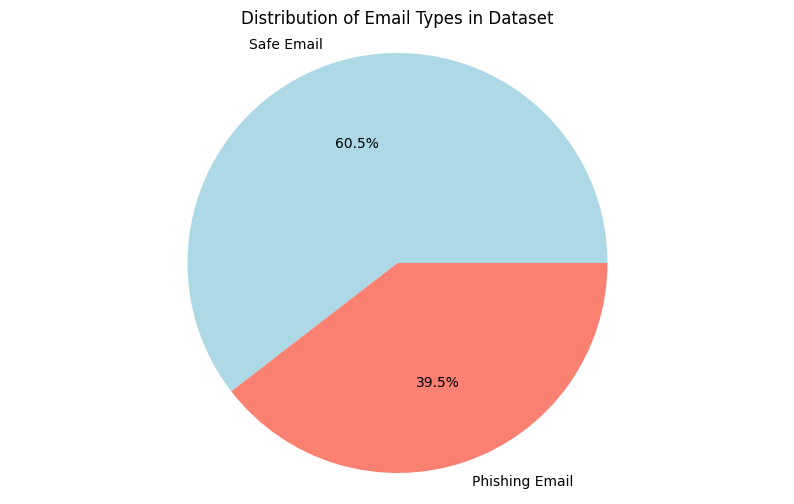

In [9]:
# EDA 1: Distribution of Email Types with percentages
plt.figure(figsize=(10, 6))
email_counts = data['Email Type'].value_counts()
plt.pie(email_counts.values, labels=email_counts.index, autopct='%1.1f%%', colors=['lightblue', 'salmon'])
plt.title('Distribution of Email Types in Dataset')
plt.axis('equal')
plt.show()

Dataset Overview:
--------------------------------------------------
Total number of emails: 18487
Number of phishing emails: 7309
Number of safe emails: 11178


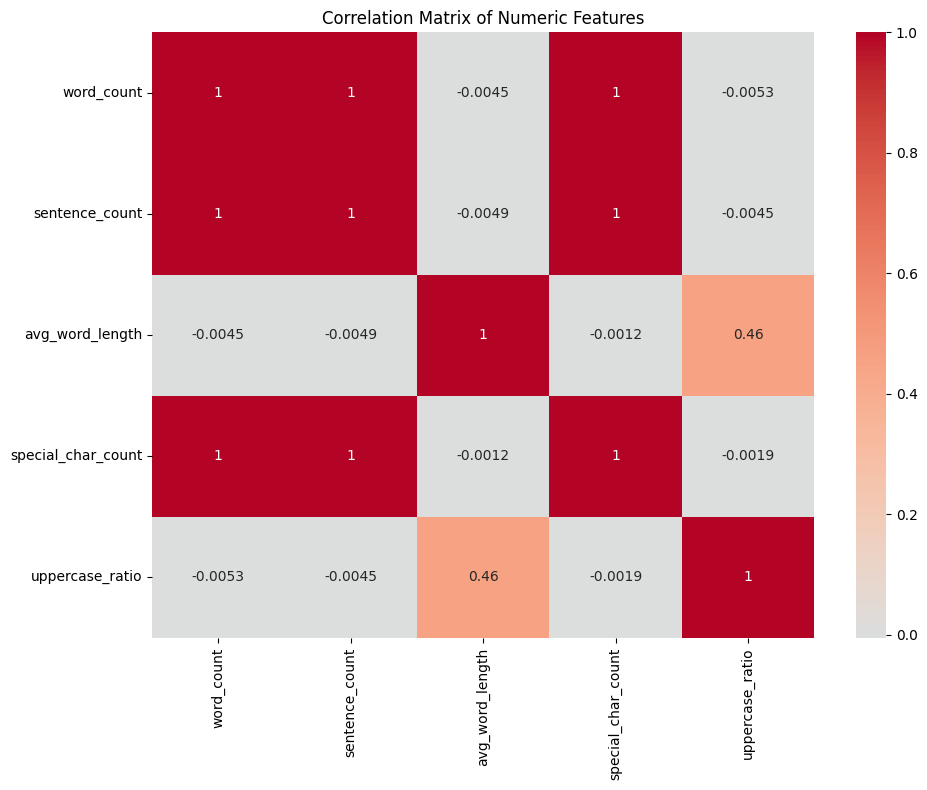

In [10]:
# EDA 2: Correlation Matrix
data['word_count'] = data['Email Text'].str.split().str.len()
data['sentence_count'] = data['Email Text'].str.count('[.!?]+')
data['avg_word_length'] = data['Email Text'].apply(lambda x: np.mean([len(word) for word in x.split()]))
data['special_char_count'] = data['Email Text'].str.count(r'[^a-zA-Z0-9\s]')
data['uppercase_ratio'] = data['Email Text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0
)

# Then show the dataset overview
print("Dataset Overview:")
print("-" * 50)
print(f"Total number of emails: {len(data)}")
print(f"Number of phishing emails: {len(data[data['Email Type'] == 'Phishing Email'])}")
print(f"Number of safe emails: {len(data[data['Email Type'] == 'Safe Email'])}")

# Now create correlation matrix
numeric_cols = ['word_count', 'sentence_count', 'avg_word_length', 
                'special_char_count', 'uppercase_ratio']
correlation_matrix = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

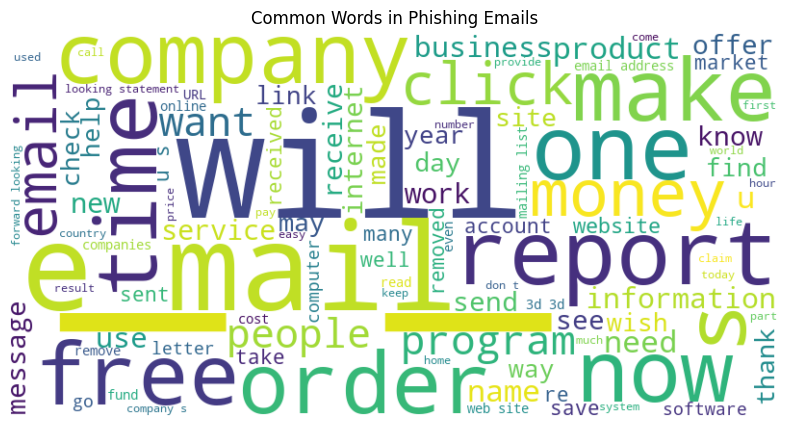

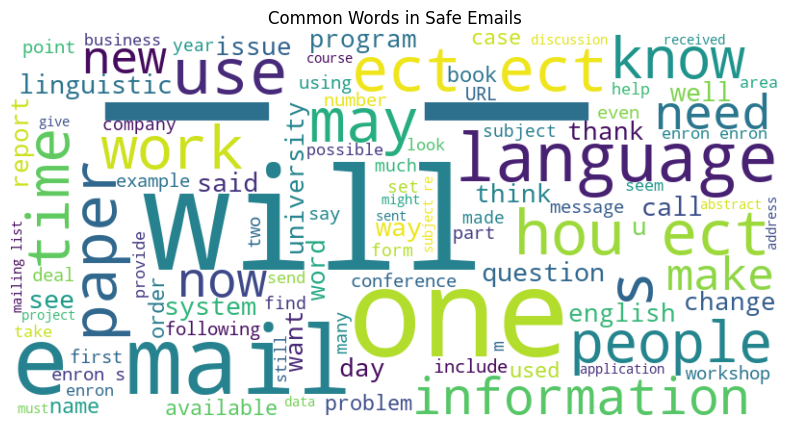


Dataset Statistics:
Total number of emails: 18487
Number of unique words in phishing emails: 107672
Number of unique words in safe emails: 180270


In [11]:
# EDA 3: Word Cloud Comparison
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400,
                         background_color='white',
                         max_words=100,
                         contour_width=3,
                         contour_color='steelblue').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Ensure all text data is string and handle missing values
data['Email Text'] = data['Email Text'].fillna('').astype(str)

# Create word clouds for both types of emails
phishing_text = ' '.join(data[data['Email Type'] == 'Phishing Email']['Email Text'])
safe_text = ' '.join(data[data['Email Type'] == 'Safe Email']['Email Text'])

create_wordcloud(phishing_text, 'Common Words in Phishing Emails')
create_wordcloud(safe_text, 'Common Words in Safe Emails')

# Additional statistical insights
print("\nDataset Statistics:")
print(f"Total number of emails: {len(data)}")
print(f"Number of unique words in phishing emails: {len(set(phishing_text.split()))}")
print(f"Number of unique words in safe emails: {len(set(safe_text.split()))}")

In [12]:
class BERTClassifier(nn.Module):
    def __init__(self, bert_model_name, num_classes):
        super(BERTClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        x = self.dropout(pooled_output)
        logits = self.fc(x)
        return logits

In [13]:
# Parameters
max_length = 256
batch_size = 16
num_classes = 2
num_epochs = 10
learning_rate = 2e-5

# Use the existing tokenizer and model
model = BERTClassifier(bert_model_name, num_classes)  # Already initialized
# Check if GPU is available and being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Add this to verify CUDA is available
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Ensure model is on GPU
model = model.to(device)
print(f"Model device: {next(model.parameters()).device}")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3060 Laptop GPU
GPU Memory: 6.44 GB
Model device: cuda:0


In [14]:
# Create datasets
train_dataset = EmailClassificationDataset(train_texts, train_labels, tokenizer, max_length)
val_dataset = EmailClassificationDataset(val_texts, val_labels, tokenizer, max_length)

# Create data loaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

In [15]:
# Optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=learning_rate)
total_steps = len(train_dataloader) * num_epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

c:\Users\chong\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [16]:
def train(model, data_loader, optimizer, scheduler, device):
    model.train()
    for batch in data_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

def evaluate(model, data_loader, device):
    model.eval()
    predictions = []
    actual_labels = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs, dim=1)
            predictions.extend(preds.cpu().tolist())
            actual_labels.extend(labels.cpu().tolist())
    return accuracy_score(actual_labels, predictions), classification_report(actual_labels, predictions)

In [66]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_accuracy = None
        self.early_stop = False
        self.best_model = None

def evaluate_with_metrics(model, dataloader, device):
    model.eval()
    predictions = []
    actual_labels = []
    probabilities = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, dim=1)
            
            predictions.extend(preds.cpu().tolist())
            actual_labels.extend(labels.cpu().tolist())
            probabilities.extend(probs[:, 1].cpu().tolist())
    
    accuracy = accuracy_score(actual_labels, predictions)
    report = classification_report(actual_labels, predictions)
    
    # Calculate AUPRC
    precision, recall, _ = precision_recall_curve(actual_labels, probabilities)
    auprc = auc(recall, precision)
    
    return accuracy, report, auprc, predictions, actual_labels, probabilities

def train_with_early_stopping(model, train_dataloader, val_dataloader, optimizer, scheduler, device, max_epochs=10):
    early_stopping = EarlyStopping(patience=5)
    
    # Lists to store metrics for plotting
    training_metrics = {
        'train_losses': [],
        'val_accuracies': [],
        'val_auprcs': [],
        'epochs': [],
        'final_metrics': None
    }
    
    for epoch in range(max_epochs):
        print(f"Epoch {epoch + 1}/{max_epochs}")
        
        # Training
        model.train()
        epoch_loss = 0
        num_batches = 0
        
        for batch in train_dataloader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = nn.CrossEntropyLoss()(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            epoch_loss += loss.item()
            num_batches += 1
        
        avg_train_loss = epoch_loss / num_batches
        training_metrics['train_losses'].append(avg_train_loss)
        
        # Evaluation
        accuracy, report, auprc, all_preds, all_labels, all_probs = evaluate_with_metrics(model, val_dataloader, device)
        training_metrics['val_accuracies'].append(accuracy)
        training_metrics['val_auprcs'].append(auprc)
        training_metrics['epochs'].append(epoch + 1)
        
        print(f"Epoch {epoch + 1}")
        print(f"Average Training Loss: {avg_train_loss:.4f}")
        print(f"Validation Accuracy: {accuracy:.4f}")
        print(f"Validation AUPRC: {auprc:.4f}")
        print(report)
        
        # Early stopping check
        if early_stopping.best_accuracy is None:
            early_stopping.best_accuracy = accuracy
            early_stopping.best_model = model.state_dict().copy()
        else:
            if accuracy > early_stopping.best_accuracy + early_stopping.min_delta:
                early_stopping.best_accuracy = accuracy
                early_stopping.counter = 0
                early_stopping.best_model = model.state_dict().copy()
            else:
                early_stopping.counter += 1
                print(f"Early stopping counter: {early_stopping.counter}/{early_stopping.patience}")
        
        if early_stopping.counter >= early_stopping.patience:
            print("Early stopping triggered!")
            model.load_state_dict(early_stopping.best_model)
            break
    
    # Store final evaluation metrics
    training_metrics['final_metrics'] = (all_labels, all_probs)
    
    return model, early_stopping.best_accuracy, training_metrics

# Train the model
model, best_accuracy, training_metrics = train_with_early_stopping(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    scheduler, 
    device
)

print(f"\nTraining completed! Best accuracy: {best_accuracy:.4f}")

Epoch 1/10
Epoch 1
Average Training Loss: 0.0910
Validation Accuracy: 0.9721
Validation AUPRC: 0.9961
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      2212
           1       0.94      1.00      0.97      1486

    accuracy                           0.97      3698
   macro avg       0.97      0.98      0.97      3698
weighted avg       0.97      0.97      0.97      3698

Epoch 2/10
Epoch 2
Average Training Loss: 0.0301
Validation Accuracy: 0.9532
Validation AUPRC: 0.9933
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2212
           1       0.96      0.92      0.94      1486

    accuracy                           0.95      3698
   macro avg       0.96      0.95      0.95      3698
weighted avg       0.95      0.95      0.95      3698

Early stopping counter: 1/5
Epoch 3/10
Epoch 3
Average Training Loss: 0.0230
Validation Accuracy: 0.9773
Validation AUPRC: 0.9971
            

In [38]:
torch.save(model.state_dict(), "bert_email_classifier.pth")

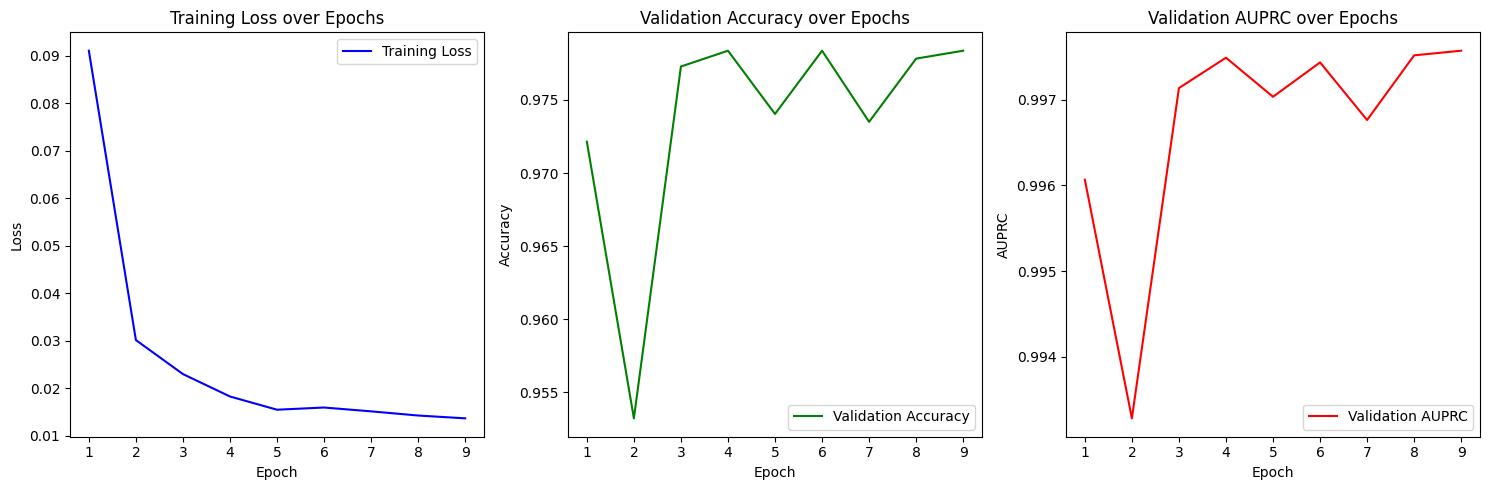

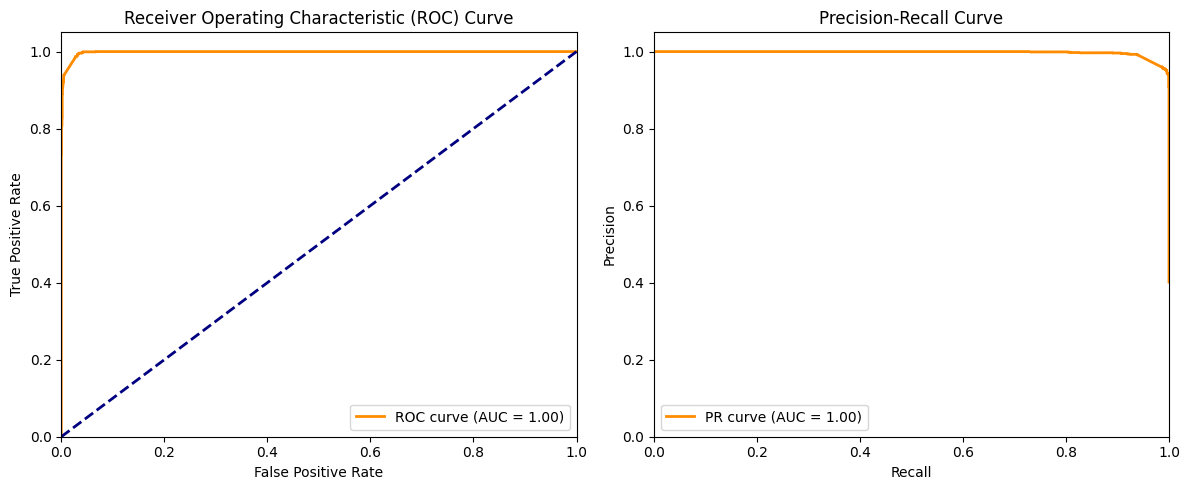

In [67]:
def plot_training_metrics(training_metrics):
    epochs = training_metrics['epochs']
    train_losses = training_metrics['train_losses']
    val_accuracies = training_metrics['val_accuracies']
    val_auprcs = training_metrics['val_auprcs']
    
    plt.figure(figsize=(15, 5))
    
    # Plot training loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot validation accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, val_accuracies, 'g-', label='Validation Accuracy')
    plt.title('Validation Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot validation AUPRC
    plt.subplot(1, 3, 3)
    plt.plot(epochs, val_auprcs, 'r-', label='Validation AUPRC')
    plt.title('Validation AUPRC over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('AUPRC')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def plot_roc_pr_curves(labels, probabilities):
    plt.figure(figsize=(12, 5))
    
    # Plot ROC curve
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(labels, probabilities)
    roc_auc = roc_auc_score(labels, probabilities)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    
    # Plot PR curve
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(labels, probabilities)
    auprc = auc(recall, precision)
    plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUC = {auprc:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

# Generate the plots
plot_training_metrics(training_metrics)
plot_roc_pr_curves(*training_metrics['final_metrics'])

In [17]:
def train_test(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in data_loader:
        optimizer.zero_grad()
        
        # Check if batch is a dictionary or a tuple
        if isinstance(batch, dict):
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
        else:
            input_ids = batch[0].to(device)
            labels = batch[1].to(device)
        
        outputs = model(input_ids)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(data_loader)

def evaluate(model, data_loader, device):
    model.eval()
    predictions = []
    actual_labels = []
    with torch.no_grad():
        for batch in data_loader:
            
            # Check if batch is a dictionary or a tuple
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                labels = batch['label'].to(device)
            else:
                input_ids = batch[0].to(device)
                labels = batch[1].to(device)
            
            outputs = model(input_ids)
            _, preds = torch.max(outputs, dim=1)
            predictions.extend(preds.cpu().tolist())
            actual_labels.extend(labels.cpu().tolist())
    return accuracy_score(actual_labels, predictions), classification_report(actual_labels, predictions)

In [21]:
# CNN Model Definition
num_classes = 2
class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, kernel_sizes, num_filters):
        super(CNNClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)  # Trainable embeddings
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k) for k in kernel_sizes
        ])
        self.batch_norms = nn.ModuleList([nn.BatchNorm1d(num_filters) for _ in kernel_sizes])  # Add batch normalization
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(len(kernel_sizes) * num_filters, num_classes)

    def forward(self, x):
        x = self.embedding(x)  # Shape: (batch_size, sequence_length, embed_dim)
        x = x.permute(0, 2, 1)  # Reshape to (batch_size, embed_dim, sequence_length) for Conv1d
        x = [torch.relu(self.batch_norms[i](conv(x))) for i, conv in enumerate(self.convs)]
        x = [torch.max_pool1d(i, i.size(2)).squeeze(2) for i in x]
        x = torch.cat(x, 1)
        x = self.dropout(x)
        return self.fc(x)

# Prepare data for CNN
def prepare_data_for_cnn(texts, tokenizer, max_length):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length)
    input_ids = torch.tensor(encodings['input_ids'])
    return input_ids

# Initialize CNN model
vocab_size = tokenizer.vocab_size
embed_dim = 128
kernel_sizes = [3, 4, 5]
num_filters = 100
cnn_model = CNNClassifier(vocab_size, embed_dim, num_classes, kernel_sizes, num_filters).to(device)

# Prepare data
train_input_ids = prepare_data_for_cnn(train_texts, tokenizer, max_length)
val_input_ids = prepare_data_for_cnn(val_texts, tokenizer, max_length)

# Create datasets and dataloaders
train_dataset_cnn = torch.utils.data.TensorDataset(train_input_ids, torch.tensor(train_labels))
val_dataset_cnn = torch.utils.data.TensorDataset(val_input_ids, torch.tensor(val_labels))
train_dataloader_cnn = DataLoader(train_dataset_cnn, batch_size=batch_size, shuffle=True)
val_dataloader_cnn = DataLoader(val_dataset_cnn, batch_size=batch_size)

# Train and evaluate CNN model
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=learning_rate)
train_test(cnn_model, train_dataloader_cnn, optimizer_cnn, device)
accuracy, report = evaluate(cnn_model, val_dataloader_cnn, device)
print(f"CNN Model Accuracy: {accuracy}")
print(report)

CNN Model Accuracy: 0.7744726879394267
              precision    recall  f1-score   support

           0       0.95      0.66      0.78      2213
           1       0.65      0.95      0.77      1485

    accuracy                           0.77      3698
   macro avg       0.80      0.80      0.77      3698
weighted avg       0.83      0.77      0.78      3698



In [25]:
# LSTM Model Definition with Attention
class AttentionLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes):
        super(AttentionLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)  # Trainable embeddings
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=0.5, bidirectional=True)  # Use bidirectional LSTM
        self.attention = nn.Linear(hidden_dim * 2, 1)  # Attention layer
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        return self.fc(context)

# Prepare data for LSTM
def prepare_data_for_lstm(texts, tokenizer, max_length):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length)
    input_ids = torch.tensor(encodings['input_ids'])
    return input_ids

# Prepare data
train_input_ids_lstm = prepare_data_for_lstm(train_texts, tokenizer, max_length)
val_input_ids_lstm = prepare_data_for_lstm(val_texts, tokenizer, max_length)

# Create datasets and dataloaders for LSTM
train_dataset_lstm = TensorDataset(train_input_ids_lstm, torch.tensor(train_labels))
val_dataset_lstm = TensorDataset(val_input_ids_lstm, torch.tensor(val_labels))
train_dataloader_lstm = DataLoader(train_dataset_lstm, batch_size=batch_size, shuffle=True)
val_dataloader_lstm = DataLoader(val_dataset_lstm, batch_size=batch_size)

# Initialize LSTM model
hidden_dim = 128
num_layers = 2
attention_lstm_model = AttentionLSTMClassifier(vocab_size, embed_dim, hidden_dim, num_layers, num_classes).to(device)

# Train and evaluate LSTM model
optimizer_attention_lstm = torch.optim.Adam(attention_lstm_model.parameters(), lr=learning_rate, weight_decay=1e-5)
train_loss = train_test(attention_lstm_model, train_dataloader_lstm, optimizer_attention_lstm, device)
accuracy, report = evaluate(attention_lstm_model, val_dataloader_lstm, device)
print(f"Attention LSTM Model Training Loss: {train_loss}")
print(f"Attention LSTM Model Accuracy: {accuracy}")
print(report)

Attention LSTM Model Training Loss: 0.6505624263561327
Attention LSTM Model Accuracy: 0.7047052460789616
              precision    recall  f1-score   support

           0       0.85      0.62      0.71      2213
           1       0.59      0.83      0.69      1485

    accuracy                           0.70      3698
   macro avg       0.72      0.73      0.70      3698
weighted avg       0.75      0.70      0.71      3698



In [32]:
def predict_email_classification(email_text, model, tokenizer, device, max_length=128):
    model.eval()
    # Tokenize the input email text
    encoding = tokenizer(
        email_text, 
        return_tensors='pt', 
        max_length=max_length, 
        padding='max_length', 
        truncation=True
    )
    
    # Move input tensors to the specified device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Perform prediction without calculating gradients
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probabilities = nn.functional.softmax(outputs, dim=1)  # Calculate probabilities
        confidence, preds = torch.max(probabilities, dim=1)  # Get the max confidence and corresponding label
    
    # Map predictions to email classification labels
    label = "Phishing Email" if preds.item() == 1 else "Safe Email"
    confidence_percentage = confidence.item() * 100  # Convert confidence to percentage
    
    return label, confidence_percentage

# Example usage
email_text = "Indicate your intake code : APD3F2405CS(AI) old title: Deep Learning-Based Scoring System for Detecting Phishing Emails, Spam, and Malicious Files new title: Deep Learning-Based Scoring System for Detecting Phishing Emails Reason to change : I am planning to put the malicious file detection as my additional feature and removing the spam. Hence, removing them from the title is more better as my main is to detect the phishing emails."
# Perform the prediction
label, confidence = predict_email_classification(email_text, model, tokenizer, device)
print(f"Email Classification: {label}")
print(f"Confidence Level: {confidence:.2f}%")

Email Classification: Phishing Email
Confidence Level: 55.33%
